Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

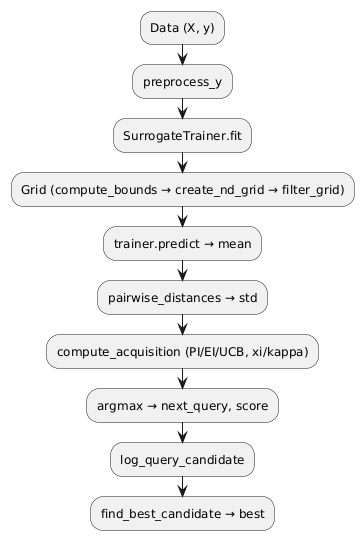

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score  source
32     0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182  week-3
6      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968    file
30     0.000000     0.500000     0.214286     0.214286     0.428572     0.714286  1.181423  week-1
31     0.060606     0.484848     0.242424     0.181818     0.484848     0.727273  0.976917  week-2
24     0.881647     0.204450     0.414474     0.420385     0.264915     0.730660  0.675142    file
14     0.148647     0.033943     0.728806     0.316066     0.021769     0.516918  0.611526    file
0      0.272624     0.324495     0.897109     0.832951     0.154063     0.795864  0.604433    file
1      0.543003     0.924694     0.341567     0.646486     0.718440     0.343133  0.562753    file
25     0.066611     0.528045     0.816095     0.961017     0.086509     0.777788  0.516457    file
33     0.1

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_58959/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


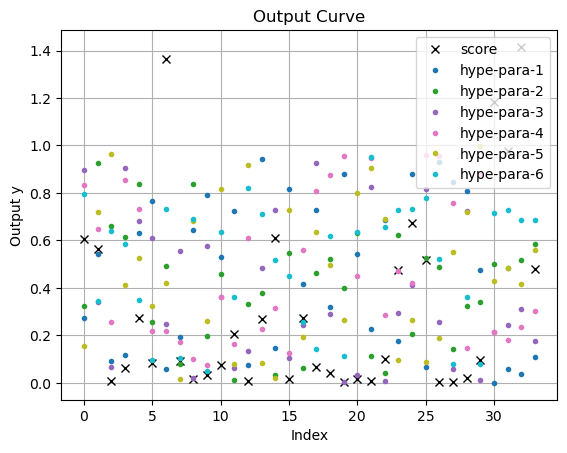

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [4]:
X = inputs
y = outputs

In [5]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [6]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[100],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")    

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        X_grid_full = create_nd_grid(bounds, grid_size, downsample=True, stride=(len(bounds) + 2))
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)
        #X_grid_filtered = X_grid_full # No filtering for NN surrogate

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)
        
        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score)

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Train Loss: 0.750466, Val Loss: 2.604031
Epoch 50/500, Train Loss: 0.169442, Val Loss: 0.886511
Epoch 100/500, Train Loss: 0.009750, Val Loss: 0.465217
Early stopping at epoch 132, best val_loss=0.389779


/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/utils/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


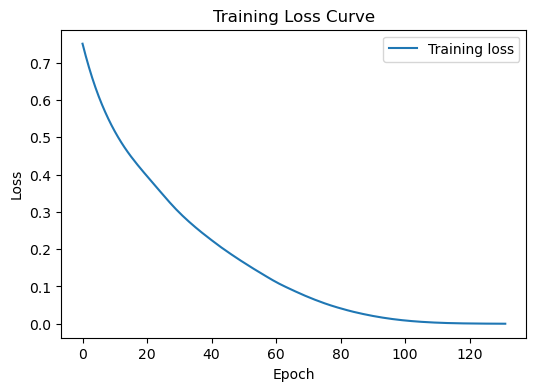

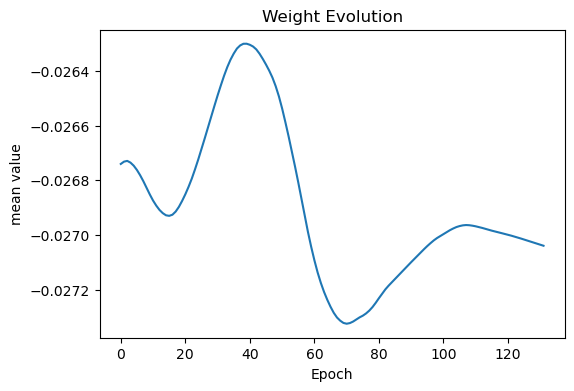

Computing bounds with margin 0.1.
Bounds per feature: [(-0.1, 1.042450839379723), (-0.08818716329132373, 1.0246939036961067), (-0.09636543517036425, 1.0245705141349382), (-0.026340812726440316, 1.0610171372277224), (-0.08505582357070765, 1.0986546964586872), (-0.04890013578635702, 1.0510139152470552)]
Using 6 dimensions.
Points before downsampling: 1000000000000
Points after downsampling: 4826809
Final grid shape: (4826809, 6)
Filtering grid using mode: median
Grid shape before filtering: (4826809, 6)
Filtered 1329907 candidates near decision boundary (|margin| < 0.2)
Excluded 3496902 candidates from consideration
Final grid shape: (1329907, 6)
Filtered grid shape: (1329907, 6)
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Computing acqui

In [7]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='median')

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


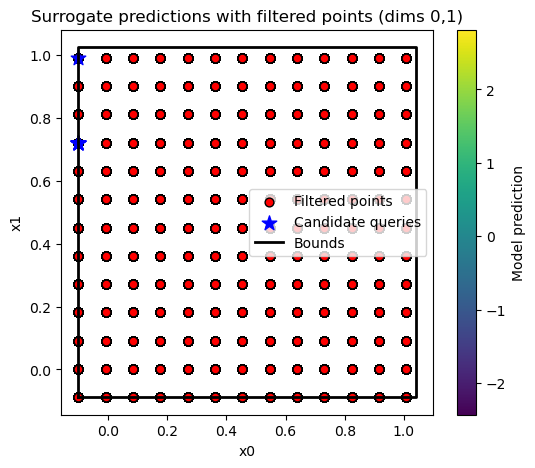

In [8]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [9]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([-0.1       ,  0.99097023,  0.99060276, -0.02634081, -0.08505582,
        1.01768319]), 'score': 5.736062282785139, 'dim': 6}


In [10]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score  source
32     0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182  week-3
6      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968    file
30     0.000000     0.500000     0.214286     0.214286     0.428572     0.714286  1.181423  week-1
31     0.060606     0.484848     0.242424     0.181818     0.484848     0.727273  0.976917  week-2
24     0.881647     0.204450     0.414474     0.420385     0.264915     0.730660  0.675142    file
14     0.148647     0.033943     0.728806     0.316066     0.021769     0.516918  0.611526    file
0      0.272624     0.324495     0.897109     0.832951     0.154063     0.795864  0.604433    file
1      0.543003     0.924694     0.341567     0.646486     0.718440     0.343133  0.562753    file
25     0.066611     0.528045     0.816095     0.961017     0.086509     0.777788  0.516457    file
33     0.1

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_58959/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


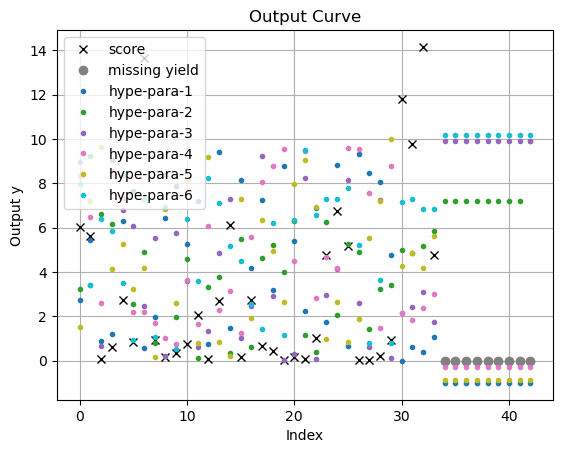

In [13]:
plot_output_points(df_sorted, scale_factor=10.0, yield_scale_factor=10.0, nan_marker='o')